# 使用深度学习预测市场走势

原书用 Keras 的 `Sequential.fit()`。本版改用 PyTorch Lightning（`LightningModule` / `Trainer` / `DataLoader` / `torchmetrics`），流程仍对应 `.fit()` / `.predict()`。

不追求复现书上印刷数字：框架与随机数实现不同；数据与标准化按更合理的做法（见下），样本内策略收益会与书不一致。


In [65]:
# !pip install pytorch-lightning torchmetrics -i https://pypi.org/simple

In [66]:
import logging
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from torchmetrics.classification import BinaryAccuracy

# Lightning 内部噪音：LeafSpec 弃用、litlogger 广告（info 日志）
warnings.filterwarnings('ignore', message=r'.*LeafSpec.*')

class _DropLitLoggerTip(logging.Filter):
    def filter(self, record):
        return 'litlogger' not in record.getMessage().lower()

logging.getLogger().addFilter(_DropLitLoggerTip())

%matplotlib inline

## 1. 简单分类问题回顾

用一个简单示例（学习时长 → 是否通过考试）说明 Lightning 的基本使用方式。

In [67]:
import numpy as np
import pandas as pd

# 构造示例数据：学习时长 -> 是否通过
hours = np.array([0.5, 0.75, 1., 1.25, 1.5, 1.75, 1.75, 2., 2.25, 2.5, 2.75, 3., 3.25, 3.5, 4., 4.25, 4.5, 4.75, 5., 5.5])
success = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

data = pd.DataFrame({'hours': hours, 'success': success})
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   hours    20 non-null     float64
 1   success  20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


In [68]:
data.head()

,hours,success
0,0.50,0
1,0.75,0
2,1.00,0
3,1.25,0
4,1.50,0


原书用 `sklearn.neural_network.MLPClassifier`, 本 notebook 使用 `LightningModule` 定义等价的网络，训练交给 `pl.Trainer` 完成。

In [69]:
class SimpleMLP(pl.LightningModule):
    def __init__(self, in_features=1, hidden=32, lr=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
            nn.Sigmoid()
        )
        self.criterion = nn.BCELoss() # 连续、可反传
        self.train_acc = BinaryAccuracy() # 有时不可反传，主要用来和业务对齐

    def forward(self, x):
        return self.net(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.train_acc(y_hat, y.int()) # 把 0.0/1.0 转成 0/1 再算命中率
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc', self.train_acc, on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        '''
        数据怎么组的	        batch 长什么样	       这一行取到什么
        TensorDataset(X, y)     元组 (x, y)     batch[0]，只要特征，丢掉标签
        TensorDataset(X)        元组 (x,)       batch[0]，同样是只要特征
        直接就是一个张量        batch 本身就是 x        整份 batch

        本行是在判断 batch 是不是 list 或 tuple，如果是，只保留特征（第一项）
        '''
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [70]:
pl.seed_everything(100, workers=True)

X = torch.tensor(data['hours'].values.reshape(-1, 1), dtype=torch.float32)
y = torch.tensor(data['success'].values.reshape(-1, 1), dtype=torch.float32)

Seed set to 100


In [71]:
'''
TensorDataset(X, y) 时是：
batch = (X_batch, y_batch)   # 外面是元组，里面每一项是张量
类型上: tuple[Tensor, Tensor]
'''
train_ds = TensorDataset(X, y)
train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=False, num_workers=2, persistent_workers=True)


In [72]:
model = SimpleMLP(in_features=1, hidden=32)
model

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (criterion): BCELoss()
  (train_acc): BinaryAccuracy()
)

In [73]:
trainer = pl.Trainer(max_epochs=1000, logger=False, enable_checkpointing=False,
                      enable_progress_bar=False, enable_model_summary=False)
trainer.fit(model, train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=1000` reached.


In [74]:
'''
TensorDataset(X) 时则是:
batch = (X_batch,)           # 仍是元组，只是只有一个张量
类型上: tuple[Tensor, ...]
'''

# trainer.predict(...) 返回的是「按 batch 切好的一串张量」，不是一整块
predict_loader = DataLoader(TensorDataset(X), batch_size=len(X), shuffle=False, num_workers=2, persistent_workers=True)

# predict 返回 list[Tensor]（每个 batch 一块），cat 拼成一整块再转 numpy
preds = torch.cat(trainer.predict(model, dataloaders=predict_loader)).numpy()

data['prediction'] = (preds > 0.5).astype(int)
data.tail()


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,hours,success,prediction
15,4.25,1,1
16,4.50,1,1
17,4.75,1,1
18,5.00,1,1
19,5.50,1,1


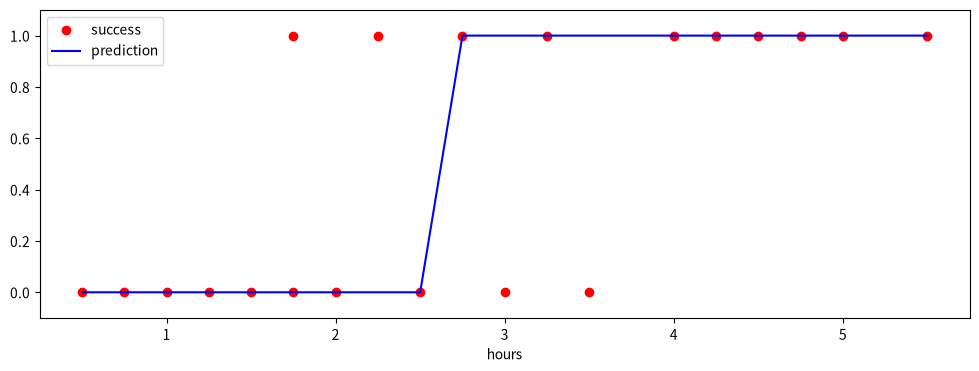

In [75]:
data.plot(x='hours', y=['success', 'prediction'],
          style=['ro', 'b-'], ylim=[-.1, 1.1],
          figsize=(12, 4));


Pytorch 里面，训练、预测都交给 `Trainer` 完成，和 Keras 的 `.fit()` / `.predict()` 用法基本对应。

## 2. 使用深度神经网络预测市场方向

接下来把这个方法应用到真实的金融时间序列（外汇对数收益率）上。

> 数据：书配套 Eikon 日频样例，本地 `data/pyalgo_eikon_eod_data.csv`（或 `http://hilpisch.com/pyalgo_eikon_eod_data.csv`）。

只取目标品种 `EUR=` 再 `dropna`。不对整张多品种表先 `raw.dropna()`（那样会因其他列缺失误删 EUR= 有效日）。


In [76]:
# 书配套样例；无本地文件时可改读作者 URL
raw = pd.read_csv(
    'data/pyalgo_eikon_eod_data.csv',
    # 'http://hilpisch.com/pyalgo_eikon_eod_data.csv',
    index_col=0,
    parse_dates=True,
)

symbol = 'EUR='
# 只保留本品种；不在整表上 dropna（避免其他符号缺数拖掉 EUR= 行）
data = pd.DataFrame(raw[symbol])
data.rename(columns={symbol: 'price'}, inplace=True)
data['return'] = np.log(data['price'] / data['price'].shift(1))
data['direction'] = np.where(data['return'] > 0, 1, 0)

lags = 5
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['return'].shift(lag)
    cols.append(col)

data.dropna(inplace=True)
data.round(4).tail()


,price,return,direction,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,,,
2019-12-26,1.1096,0.0005,1,0.0003,0.0001,0.0007,-0.0038,0.0008
2019-12-27,1.1175,0.0071,1,0.0005,0.0003,0.0001,0.0007,-0.0038
2019-12-30,1.1197,0.0020,1,0.0071,0.0005,0.0003,0.0001,0.0007
2019-12-31,1.1210,0.0012,1,0.0020,0.0071,0.0005,0.0003,0.0001
2020-01-01,1.1210,0.0000,0,0.0012,0.0020,0.0071,0.0005,0.0003


### 2.1 滞后收益率与市场方向的关系

在输入神经网络之前，先检查各阶滞后收益与当日 `direction` 的相关系数。若相关接近于零，则样本内表现再好，仍须以样本外结果作为主要依据。


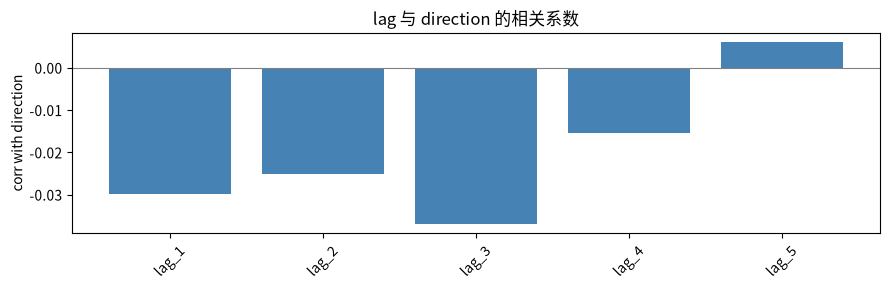

lag_1   -0.0299
lag_2   -0.0252
lag_3   -0.0370
lag_4   -0.0154
lag_5    0.0060


In [77]:
import matplotlib.pyplot as plt

# DejaVu Sans 不含中文；本机用 Noto Sans CJK SC
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

corr = data[cols].corrwith(data['direction'])
# Pearson: corr(x,y) = Cov(x,y) / (std(x)*std(y))，对每个 lag 列分别与 direction 算一遍

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(cols)), corr.values, color='steelblue')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45)
ax.set_ylabel('corr with direction')
ax.set_title('lag 与 direction 的相关系数')
fig.tight_layout()
plt.show()
print(corr.round(4).to_string())


各阶 `lag` 与 `direction` 的相关系数均接近于零，这表明滞后收益与当日涨跌方向几乎不存在稳定的线性相关；后续模型若在样本内表现突出，更需依赖样本外评估加以检验。

### 2.2 定义 Lightning 版 DNN 分类器

用 `LightningModule` 定义网络：两层隐藏单元（各 64）+ `ReLU`，输出经 `Sigmoid`；损失为 `BCELoss`，优化器用 `Adam(lr=0.0001)`。

`training_step` / `validation_step` 供 `fit` 使用；`predict_step` 在训练结束后取出上涨概率。本笔记的样本内/外评估都走 `predict`，不再调用 `trainer.test`（避免把「测试集」与 API 名 `test` 混在一起）。

`training_step` 与 `validation_step` 的前向与损失相同，差异在日志名与准确率度量。是否反传由 `Trainer` 决定：仅训练循环对 `training_step` 的 loss 做 `backward`；验证循环在 `no_grad` 下运行。


In [78]:
class DNNClassifier(pl.LightningModule):
    def __init__(self, n_features, hidden=64, lr=0.0001):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1), nn.Sigmoid()
        )
        self.criterion = nn.BCELoss()
        self.train_acc = BinaryAccuracy()
        self.val_acc = BinaryAccuracy()

    def forward(self, x):
        return self.net(x)

    def _step(self, batch, acc_metric, loss_name, acc_name):
        """训练/验证共用的前向与损失；是否反传由 Trainer 的循环阶段决定。"""
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc_metric(y_hat, y.int())
        self.log(loss_name, loss, on_epoch=True, on_step=False)
        self.log(acc_name, acc_metric, on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx):
        # Trainer 会对这里返回的 loss 做 backward + optimizer.step
        return self._step(batch, self.train_acc, 'train_loss', 'train_acc')

    def validation_step(self, batch, batch_idx):
        # 由 Trainer 在 no_grad 下调用，返回的 loss 只用于记录，不反传
        return self._step(batch, self.val_acc, 'val_loss', 'val_acc')

    def predict_step(self, batch, batch_idx, dataloader_idx=0):
        x = batch[0] if isinstance(batch, (list, tuple)) else batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [ ]:
cutoff = '2017-12-31'
val_ratio = 0.2
features = cols  # lag_1, ...

# 1) 按时间切开：cutoff 前 = 样本内池，cutoff 后 = test
insample_df = data.loc[data.index < cutoff].copy()
test_df = data.loc[data.index >= cutoff].copy()

# 2) 样本内池再按时间切 train / val（末尾 20%，对应 Keras validation_split + shuffle=False）
n_val = int(len(insample_df) * val_ratio)
train_df = insample_df.iloc[:-n_val]
val_df = insample_df.iloc[-n_val:]

# 3) 与书一致：mu/std 在整个 insample（cutoff 前）上估计，再套到 train/val/test
mu, std = insample_df[features].mean(), insample_df[features].std()

X_train = ((train_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_train = train_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_val = ((val_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_val = val_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_test = ((test_df[features] - mu) / std).to_numpy(dtype=np.float32)  # 用 insample 的 mu/std
y_test = test_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_insample = ((insample_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_insample = insample_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  features={len(features)}')


train=1664  val=416  test=523  features=5


一次切好三个 `DataLoader`：

- `train_loader` / `val_loader`：供 `trainer.fit`
- `test_loader`：持出集，训练不碰；样本外可对 `X_test` 做 `predict`

`mu` / `std` 与书一致，在整个 `insample_df`（cutoff 前）上估计，再套到 train / val / test。`fit` 与 `predict` 都用标准化后的特征（书里 `fit` 偶发写成未标准化的 `training_data[cols]`，这里不跟）。


In [80]:
%%time
pl.seed_everything(100, workers=True)

model = DNNClassifier(n_features=len(cols))
logger = CSVLogger(save_dir='lightning_logs', name='dnn_classifier')

trainer = pl.Trainer(max_epochs=50,
                     logger=logger,
                     enable_checkpointing=False,
                     enable_progress_bar=False,
                     enable_model_summary=False,
                     deterministic=True)
trainer.fit(model, train_loader, val_loader)


Seed set to 100
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 7.62 s, sys: 349 ms, total: 7.97 s
Wall time: 8.21 s


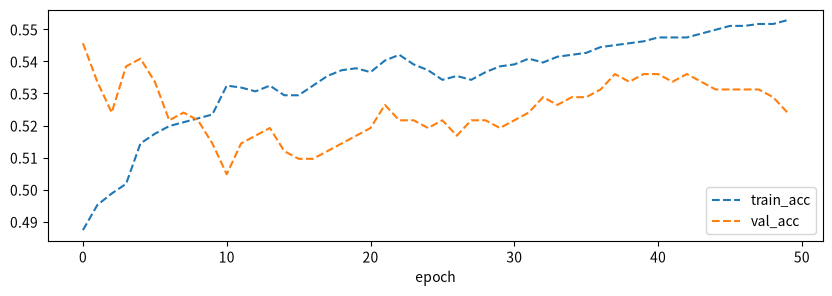

In [81]:
metrics = pd.read_csv(f'{logger.log_dir}/metrics.csv')
res = metrics.groupby('epoch')[['train_acc', 'val_acc']].mean().dropna()
res.plot(figsize=(10, 3), style='--');


In [82]:
def predict_proba(trainer, model, X, batch_size=64):
    """fit 之后用 predict 取上涨概率（不必走 trainer.test）。"""
    loader = DataLoader(
        TensorDataset(torch.as_tensor(X, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        persistent_workers=True,
    )
    return torch.cat(trainer.predict(model, dataloaders=loader))


def loss_and_acc(proba, y):
    """根据概率与标签手算 BCE 与准确率。"""
    y = torch.as_tensor(y, dtype=torch.float32).reshape(-1, 1)
    loss = nn.BCELoss()(proba, y)
    acc = ((proba > 0.5).int() == y.int()).float().mean()
    return float(loss), float(acc)


### 2.3 样本内（in-sample）评估

`fit` 结束后，对 cutoff 前全部样本（`X_insample`，含 train+val）做 `predict`，再手算 loss / accuracy；同一串概率随后映射为多空仓位。


In [83]:
proba = predict_proba(trainer, model, X_insample)
loss, acc = loss_and_acc(proba, y_insample)
print(f'样本内  loss={loss:.4f}  acc={acc:.4f}')

insample_df['prediction'] = np.where(proba.numpy() > 0.5, 1, -1)  # 预测下一期上涨的概率>0.5 则做多，否则做空
insample_df['prediction'].value_counts()


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


样本内  loss=0.6829  acc=0.5500


prediction
-1    1147
 1     933
Name: count, dtype: int64

In [84]:
insample_df['strategy'] = insample_df['prediction'] * insample_df['return']
insample_df[['return', 'strategy']].sum().apply(np.exp)


return      0.832362
strategy    2.433254
dtype: float64

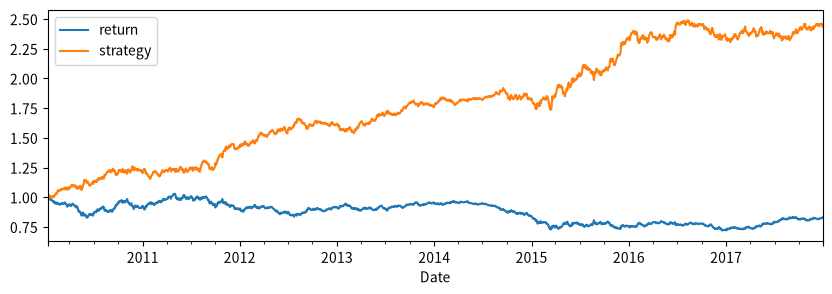

In [85]:
insample_df[['return', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 3));

### 2.4 样本外（out-of-sample）评估

对持出的 `test_loader` / `X_test` 同样用 `predict` 取概率，再手算 loss / accuracy，并映射为多空仓位。


In [86]:
proba = predict_proba(trainer, model, X_test)
loss, acc = loss_and_acc(proba, y_test)
print(f'样本外  loss={loss:.4f}  acc={acc:.4f}')

test_df['prediction'] = np.where(proba.numpy() > 0.5, 1, -1)  # 预测下一期上涨的概率>0.5 则做多，否则做空
test_df['prediction'].value_counts()


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


样本外  loss=0.6933  acc=0.5010


prediction
-1    286
 1    237
Name: count, dtype: int64

In [87]:
test_df['strategy'] = test_df['prediction'] * test_df['return']
test_df[['return', 'strategy']].sum().apply(np.exp)


return      0.934478
strategy    1.044732
dtype: float64

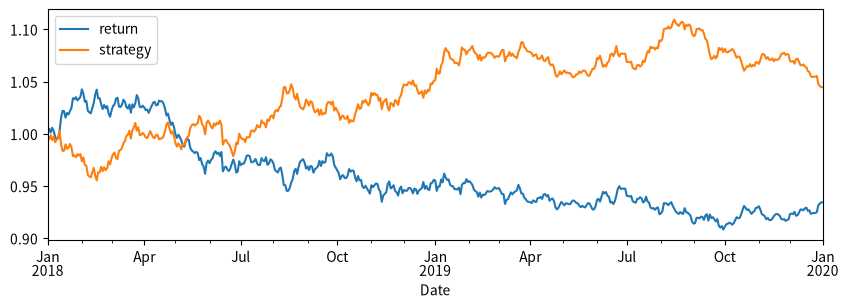

In [88]:
test_df[['return', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 3));


### 2.5 小结

in-sample 与 out-of-sample 对照（以本机最近一次运行为例；重跑后绝对数字会因随机性略变，相对结论通常不变）：

| | buy-and-hold gross performance | strategy gross performance |
|---|---|---|
| in-sample | 约 0.83（EUR= 亏损） | 约 2.7（明显高于 buy-and-hold） |
| out-of-sample | 约 0.93（EUR= 亏损） | 约 1.05（略高于 buy-and-hold） |

`sum().apply(np.exp)` 得到区间终点的 gross performance。 `cumsum().apply(np.exp)` 得到对应的 equity curve。

基准是 buy-and-hold；策略每日仓位为预测的 +1 / -1，当日损益为 `prediction * return`。

in-sample 两条 equity curve 很快分叉，strategy 抬升；out-of-sample 贴得更近，优势较小。

#### 通过对比可以得到：

1. in-sample 好看不能当真：模型在 cutoff 前训练（并用其中一部分做了 validation），再在同一时段回测，容易高估 trading edge。
2. out-of-sample 更接近可检验的结论：out of sample accuracy=0.5, 几乎接近抛硬币。strategy performence 相对 buy-and-hold performence 也只有很弱的优势。说明仅靠几阶滞后收益，DNN 并没有学到稳定可泛化的方向信号（与 2.1 节相关接近于零一致）。
3. 上述均为未计 transaction costs；一旦加入手续费，out-of-sample 那点优势很容易消失。
4. 判断模型有没有用，应看 out-of-sample equity curve，而不是 in-sample equity curve。

## 3. 增加更多类型的特征

除了对数收益率之外，再加入动量、波动率、价格偏离均线的距离等特征。

In [89]:
data.head(3)

,price,return,direction,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,,,
2010-01-11,1.4513,0.006984,1,0.006544,-0.006544,0.003058,-0.002988,0.006125
2010-01-12,1.4494,-0.001310,0,0.006984,0.006544,-0.006544,0.003058,-0.002988
2010-01-13,1.4510,0.001103,1,-0.001310,0.006984,0.006544,-0.006544,0.003058


In [90]:
data['momentum'] = data['return'].rolling(5).mean().shift(1)
data['volatility'] = data['return'].rolling(20).std().shift(1)
data['distance'] = (data['price'] - data['price'].rolling(50).mean()).shift(1)
data.dropna(inplace=True)

cols.extend(['momentum', 'volatility', 'distance'])
data.round(4).tail()


,price,return,direction,lag_1,lag_2,lag_3,lag_4,lag_5,momentum,volatility,distance
Date,,,,,,,,,,,
2019-12-26,1.1096,0.0005,1,0.0003,0.0001,0.0007,-0.0038,0.0008,-0.0004,0.0023,0.0007
2019-12-27,1.1175,0.0071,1,0.0005,0.0003,0.0001,0.0007,-0.0038,-0.0004,0.0023,0.0014
2019-12-30,1.1197,0.0020,1,0.0071,0.0005,0.0003,0.0001,0.0007,0.0017,0.0028,0.0093
2019-12-31,1.1210,0.0012,1,0.0020,0.0071,0.0005,0.0003,0.0001,0.0020,0.0025,0.0114
2020-01-01,1.1210,0.0000,0,0.0012,0.0020,0.0071,0.0005,0.0003,0.0022,0.0025,0.0125


重新划分 train / val / test，只对特征做归一化；输入维度改为新特征数（隐藏层 64→32）。规则与第 2 节相同：`mu`/`std` 来自整个 insample，三个 loader 一次备齐。


In [91]:
# 特征列已在上一格更新；同样一次切好三个 loader（mu/std 用整个 insample）
features = cols
insample_df = data.loc[data.index < cutoff].copy()
test_df = data.loc[data.index >= cutoff].copy()

n_val = int(len(insample_df) * val_ratio)
train_df = insample_df.iloc[:-n_val]
val_df = insample_df.iloc[-n_val:]

mu, std = insample_df[features].mean(), insample_df[features].std()

X_train = ((train_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_train = train_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_val = ((val_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_val = val_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_test = ((test_df[features] - mu) / std).to_numpy(dtype=np.float32)  # 用 insample 的 mu/std
y_test = test_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

X_insample = ((insample_df[features] - mu) / std).to_numpy(dtype=np.float32)
y_insample = insample_df['direction'].to_numpy(dtype=np.float32).reshape(-1, 1)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=32, shuffle=False, num_workers=2, persistent_workers=True)

print(f'train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  features={len(features)}')


train=1624  val=406  test=523  features=8


In [92]:
%%time
pl.seed_everything(100, workers=True)

model = DNNClassifier(n_features=len(cols), hidden=32)
trainer = pl.Trainer(max_epochs=25, logger=False, enable_checkpointing=False,
                      enable_progress_bar=False, enable_model_summary=False,
                      deterministic=True)
trainer.fit(model, train_loader, val_loader)


Seed set to 100
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=25` reached.


CPU times: user 3.59 s, sys: 200 ms, total: 3.79 s
Wall time: 3.91 s


### 3.1 样本内评估（含新特征）

同样用 `predict` 取概率并手算指标，再构建多空策略。


In [93]:
proba = predict_proba(trainer, model, X_insample)
loss, acc = loss_and_acc(proba, y_insample)
print(f'样本内  loss={loss:.4f}  acc={acc:.4f}')

insample_df['prediction'] = np.where(proba.numpy() > 0.5, 1, -1)  # 预测下一期上涨的概率>0.5 则做多，否则做空
print(insample_df['prediction'].value_counts())

insample_df['strategy'] = insample_df['prediction'] * insample_df['return']
insample_df[['return', 'strategy']].sum().apply(np.exp)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


样本内  loss=0.6903  acc=0.5167
prediction
-1    1046
 1     984
Name: count, dtype: int64


return      0.886557
strategy    1.129014
dtype: float64

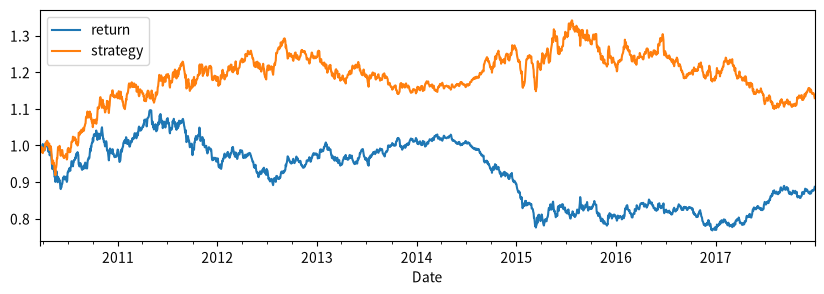

In [94]:
insample_df[['return', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 3));


### 3.2 样本外评估（含新特征）

持出集上同样：`predict` → 手算 loss/acc → 多空仓位与策略收益。


In [95]:
proba = predict_proba(trainer, model, X_test)
loss, acc = loss_and_acc(proba, y_test)
print(f'样本外  loss={loss:.4f}  acc={acc:.4f}')

test_df['prediction'] = np.where(proba.numpy() > 0.5, 1, -1)  # 预测下一期上涨的概率>0.5 则做多，否则做空
print(test_df['prediction'].value_counts())

test_df['strategy'] = test_df['prediction'] * test_df['return']
test_df[['return', 'strategy']].sum().apply(np.exp)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


样本外  loss=0.6926  acc=0.5048
prediction
-1    344
 1    179
Name: count, dtype: int64


return      0.934478
strategy    1.042065
dtype: float64

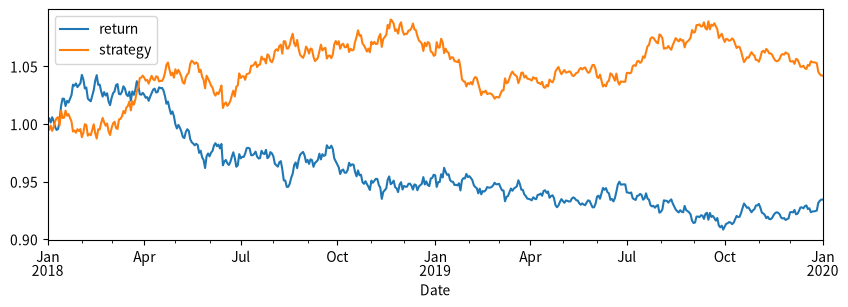

In [97]:
test_df[['return', 'strategy']].cumsum().apply(np.exp).plot(figsize=(10, 3));


### 3.3 小结

与第 2 节（仅滞后收益）对照：

| | | buy-and-hold gross performance | strategy gross performance | accuracy |
|---|---|---|---|---|
| 仅 lags（§2） | in-sample | 约 0.83 | 约 2.7 | 约 0.55 |
| 仅 lags（§2） | out-of-sample | 约 0.93 | 约 1.05 | 约 0.50 |
| + momentum / volatility / distance（§3） | in-sample | 约 0.89 | 约 1.13 | 约 0.52 |
| + momentum / volatility / distance（§3） | out-of-sample | 约 0.93 | 约 1.04 | 约 0.50 |

#### 对 strategy performance / equity curve 的作用

1. in-sample：
- 新特征没有带来更强的 trading edge. 
- strategy gross performance 从约 2.7 掉到约 1.13，
- strategy equity curve 相对 buy-and-hold equity curve 的抬升明显变弱；
- accuracy 也略降。
- 部分原因是 rolling 特征 `dropna` 后样本变短、网络隐藏层也从 64 调到 32，但即便如此，也看不到 "特征更丰富 → 策略在样本内更赚钱"的故事。

2. out-of-sample：
- 几乎没有实质改善。
- accuracy 仍接近抛硬币；
- strategy gross performance 仍只略高于 buy-and-hold（约 1.04 vs 1.05），
- 两条 equity curve 依旧贴得很近。

3. 结论：
- 在本设定下，momentum / volatility / distance 没有把方向预测做成稳定的 out-of-sample edge；
- 第 2 节里好看的 in-sample equity curve，更像过拟合或样本内运气，而不是“缺少特征”。
- 要继续研究，应优先看考虑成本后的 out-of-sample，而不是再堆同类技术指标，指望 in-sample 曲线变得更好看。

## 4. 结论

预测市场走势一直是金融领域最具吸引力的目标之一。本笔记本展示了如何用 PyTorch Lightning 搭建的神经网络，基于历史对数收益率及动量、波动率、距离等衍生特征，去预测汇率的涨跌方向，并在此基础上构建简单的多空策略。

样本内的结果通常比较乐观，但更可靠的判断需要看样本外表现，并且要把交易成本考虑进去——本笔记本的策略收益都是"不计交易成本"的毛收益。

这里展示的方法并不是稳赚不赔的"圣杯"，而是提供了一个可以继续扩展的起点：比如可以尝试不同的网络结构、更多的特征、不同的持有周期，或者利用 Lightning 的 `LightningDataModule`、`Callback`、`Trainer(accelerator="gpu")` 等机制，把整个流程封装成一个更系统化、更易复用的回测框架。